# FNSPID development negative-share double sort

**Objective.** Turn Notebook 71's conditional rank coefficient into an
examiner-readable, model-free economic magnitude. Within each development
session, firms are first placed into mean-sentiment quintiles. Inside each
quintile, the next-open return of high-negative-share firm-days is compared
with low-negative-share firm-days.

**Status.** Descriptive analysis on already-opened development data. The
design is declared in `examiner_facing_analysis_pack_v1_20260812.json`. It
does not open the 2020--2023 evaluation block or change Gate F1.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import norm

ROOT = Path.cwd().resolve()
if ROOT.name == "experiments":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402

apply_house_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

SEED = 20260812
HAC_LAGS = 5
MIN_CELL_FIRMS = 5
MIN_QUINTILES_PER_SESSION = 3
OUTPUT = ROOT / "experiments/generated/76_fnspid_development_negative_share_double_sort"
FIGURE_OUTPUT = ROOT / "manuscript/figures/fig_conditional_double_sort.png"
SPEC_PATH = ROOT / "experiments/specs/examiner_facing_analysis_pack_v1_20260812.json"
INPUT_PATH = ROOT / "experiments/generated/03_aggregation/firm_day_aggregators.parquet"
OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURE_OUTPUT.parent.mkdir(parents=True, exist_ok=True)


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def newey_west_mean(values: pd.Series, lags: int = HAC_LAGS) -> dict[str, float | int]:
    """Mean and Bartlett-kernel HAC interval without fitting a regression."""
    x = pd.Series(values, dtype=float).dropna().to_numpy()
    n = len(x)
    if n <= lags + 1:
        raise ValueError("not enough observations for the declared HAC lag")
    centred = x - x.mean()
    long_run_variance = float(np.dot(centred, centred) / n)
    for lag in range(1, lags + 1):
        weight = 1.0 - lag / (lags + 1.0)
        covariance = float(np.dot(centred[lag:], centred[:-lag]) / n)
        long_run_variance += 2.0 * weight * covariance
    se = math.sqrt(max(long_run_variance, 0.0) / n)
    z = float(x.mean() / se) if se > 0 else float("nan")
    return {
        "n_sessions": n,
        "mean_bps": float(x.mean()),
        "hac_se_bps": se,
        "ci_low_bps": float(x.mean() - norm.ppf(0.975) * se),
        "ci_high_bps": float(x.mean() + norm.ppf(0.975) * se),
        "z": z,
        "p_two_sided_descriptive": float(2.0 * norm.sf(abs(z))) if np.isfinite(z) else float("nan"),
        "hac_lags": lags,
    }


print(f"repo:   {ROOT}")
print(f"output: {OUTPUT}")
print(f"input:  {INPUT_PATH.relative_to(ROOT)}")

repo:   /Users/peterprendergast/Documents/Sentiment_Dissertation
output: /Users/peterprendergast/Documents/Sentiment_Dissertation/experiments/generated/76_fnspid_development_negative_share_double_sort
input:  experiments/generated/03_aggregation/firm_day_aggregators.parquet


## Declared design and input identity

- Development observations only; no evaluation rows are used.
- Mean sentiment is split into five within-session average-tie rank buckets.
- Negative share is split into dependent terciles inside each mean quintile.
  Tied values are allocated fractionally across terciles, so every tercile
  receives one third of the cell weight without an arbitrary symbol tie-break.
- Each cell needs five firms. A pooled daily spread needs at least three of
  the five mean-sentiment quintiles.
- The primary display uses all complete firm-days. The `n >= 2` panel is a
  declared mechanism sensitivity because single-story days have no genuine
  within-day distribution.

In [2]:
spec = json.loads(SPEC_PATH.read_text())
declared = spec["notebook_76"]
assert declared["minimum_cell_firms"] == MIN_CELL_FIRMS
assert declared["minimum_available_mean_quintiles_per_session"] == MIN_QUINTILES_PER_SESSION
if not INPUT_PATH.exists():
    raise FileNotFoundError(INPUT_PATH)

input_hash = sha256(INPUT_PATH)
panel = pd.read_parquet(INPUT_PATH)
panel["session_date"] = pd.to_datetime(panel["session_date"]).dt.normalize()
development = panel.loc[panel["split"].eq("development")].copy()
required = ["session_date", "symbol", "mean_continuous", "negative_share", "n", "ar_open_h1"]
missing = set(required) - set(development.columns)
if missing:
    raise ValueError(f"missing required columns: {sorted(missing)}")
development = development.dropna(subset=required).copy()
if development.duplicated(["session_date", "symbol"]).any():
    raise ValueError("development panel is not unique by session and symbol")
if not development["negative_share"].between(0.0, 1.0).all():
    raise ValueError("negative_share falls outside [0, 1]")
if development["session_date"].max() > pd.Timestamp("2019-12-31"):
    raise ValueError("evaluation observations entered the development figure")

input_audit = pd.DataFrame(
    [
        {
            "path": str(INPUT_PATH.relative_to(ROOT)),
            "sha256": input_hash,
            "complete_development_rows": len(development),
            "sessions": development["session_date"].nunique(),
            "symbols": development["symbol"].nunique(),
            "first_session": development["session_date"].min(),
            "last_session": development["session_date"].max(),
            "single_story_share": float(development["n"].eq(1).mean()),
        }
    ]
)
display(input_audit)

,path,sha256,complete_development_rows,sessions,symbols,first_session,last_session,single_story_share
0,experiments/generated/03_aggregation/firm_...,1ca1c38109bc06af232119adeff17de66a567174d45703...,512149,2264,570,2011-01-03,2019-12-31,0.483199


## Construct the dependent double sort

In [3]:
def build_double_sort(frame: pd.DataFrame, sample: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    work = frame.copy()
    work["mean_rank"] = work.groupby("session_date", sort=False)["mean_continuous"].rank(
        method="average", pct=True
    )
    work["mean_quintile"] = np.ceil(work["mean_rank"] * 5.0).clip(1, 5).astype(int)
    work["return_bps"] = 10_000.0 * work["ar_open_h1"]
    group = ["session_date", "mean_quintile"]
    work["cell_n"] = work.groupby(group, sort=False)["symbol"].transform("size").astype(float)
    work["tie_start"] = work.groupby(group, sort=False)["negative_share"].rank(method="min") - 1.0
    work["tie_end"] = work.groupby(group, sort=False)["negative_share"].rank(method="max")
    work["tie_n"] = work["tie_end"] - work["tie_start"]
    bounds = {
        "low": (0.0, 1.0 / 3.0),
        "middle": (1.0 / 3.0, 2.0 / 3.0),
        "high": (2.0 / 3.0, 1.0),
    }
    for bucket, (lower_share, upper_share) in bounds.items():
        lower = lower_share * work["cell_n"]
        upper = upper_share * work["cell_n"]
        overlap = np.maximum(
            0.0,
            np.minimum(work["tie_end"], upper) - np.maximum(work["tie_start"], lower),
        )
        work[f"weight_{bucket}"] = overlap / work["tie_n"]
        work[f"return_num_{bucket}"] = work[f"weight_{bucket}"] * work["return_bps"]
        work[f"negative_share_num_{bucket}"] = work[f"weight_{bucket}"] * work["negative_share"]
        work[f"mean_continuous_num_{bucket}"] = work[f"weight_{bucket}"] * work["mean_continuous"]

    aggregations: dict[str, tuple[str, str]] = {
        "n_firms": ("symbol", "size"),
        "mean_story_count": ("n", "mean"),
    }
    for bucket in bounds:
        aggregations[f"weight_{bucket}"] = (f"weight_{bucket}", "sum")
        aggregations[f"return_num_{bucket}"] = (f"return_num_{bucket}", "sum")
        aggregations[f"negative_share_num_{bucket}"] = (f"negative_share_num_{bucket}", "sum")
        aggregations[f"mean_continuous_num_{bucket}"] = (f"mean_continuous_num_{bucket}", "sum")
    cells = work.groupby(group, as_index=False).agg(**aggregations)
    cells["eligible_cell"] = cells["n_firms"].ge(MIN_CELL_FIRMS)
    for bucket in bounds:
        cells[f"return_bps_{bucket}"] = cells[f"return_num_{bucket}"] / cells[f"weight_{bucket}"]
        cells[f"negative_share_{bucket}"] = cells[f"negative_share_num_{bucket}"] / cells[f"weight_{bucket}"]
        cells[f"mean_continuous_{bucket}"] = cells[f"mean_continuous_num_{bucket}"] / cells[f"weight_{bucket}"]
    spreads = cells.loc[cells["eligible_cell"]].copy()
    spreads["spread_bps"] = spreads["return_bps_high"] - spreads["return_bps_low"]
    spreads["low_n_firms"] = spreads["weight_low"]
    spreads["high_n_firms"] = spreads["weight_high"]
    spreads["mean_sentiment_gap"] = spreads["mean_continuous_high"] - spreads["mean_continuous_low"]
    spreads["negative_share_gap"] = spreads["negative_share_high"] - spreads["negative_share_low"]
    spreads["sample"] = sample

    daily = (
        spreads.groupby("session_date", as_index=False)
        .agg(
            spread_bps=("spread_bps", "mean"),
            available_mean_quintiles=("mean_quintile", "nunique"),
            mean_sentiment_gap=("mean_sentiment_gap", "mean"),
        )
    )
    daily = daily.loc[daily["available_mean_quintiles"].ge(MIN_QUINTILES_PER_SESSION)].copy()
    daily["sample"] = sample
    cells["sample"] = sample
    return cells, spreads, daily


samples = {
    "all_firm_days": development,
    "multi_story_n_ge_2": development.loc[development["n"].ge(2)].copy(),
}
cell_tables = []
spread_tables = []
daily_tables = []
for sample, frame in samples.items():
    cells, spreads, daily = build_double_sort(frame, sample)
    cell_tables.append(cells)
    spread_tables.append(spreads)
    daily_tables.append(daily)

cell_table = pd.concat(cell_tables, ignore_index=True)
spread_table = pd.concat(spread_tables, ignore_index=True)
daily_table = pd.concat(daily_tables, ignore_index=True)

coverage_rows = []
for sample, frame in samples.items():
    sample_cells = cell_table.loc[cell_table["sample"].eq(sample)]
    sample_spreads = spread_table.loc[spread_table["sample"].eq(sample)]
    sample_daily = daily_table.loc[daily_table["sample"].eq(sample)]
    coverage_rows.append(
        {
            "sample": sample,
            "firm_days": len(frame),
            "sessions_in_input": frame["session_date"].nunique(),
            "eligible_mean_quintile_cells": int(sample_cells["eligible_cell"].sum()),
            "quintile_session_spreads": len(sample_spreads),
            "sessions_in_pooled_spread": len(sample_daily),
            "mean_available_quintiles": float(sample_daily["available_mean_quintiles"].mean()),
            "mean_within_quintile_sentiment_gap": float(sample_spreads["mean_sentiment_gap"].mean()),
        }
    )
coverage = pd.DataFrame(coverage_rows)
display(coverage)

,sample,firm_days,sessions_in_input,eligible_mean_quintile_cells,quintile_session_spreads,sessions_in_pooled_spread,mean_available_quintiles,mean_within_quintile_sentiment_gap
0,all_firm_days,512149,2264,11320,11320,2264,5.000000,-0.106419
1,multi_story_n_ge_2,264679,2264,11318,11318,2264,4.999117,-0.082291


## Return spreads in basis points

A negative spread means firms with a high fraction of negative headlines
subsequently underperform firms with a low fraction, despite first being
placed in the same mean-sentiment bucket.

In [4]:
quintile_rows = []
pooled_rows = []
for sample in samples:
    sample_spreads = spread_table.loc[spread_table["sample"].eq(sample)]
    for quintile, values in sample_spreads.groupby("mean_quintile")["spread_bps"]:
        quintile_rows.append({"sample": sample, "mean_quintile": int(quintile), **newey_west_mean(values)})
    pooled = daily_table.loc[daily_table["sample"].eq(sample), "spread_bps"]
    pooled_rows.append({"sample": sample, "mean_quintile": "pooled", **newey_west_mean(pooled)})

quintile_summary = pd.DataFrame(quintile_rows)
pooled_summary = pd.DataFrame(pooled_rows)
display(quintile_summary)
display(pooled_summary)

cell_return_rows = []
for bucket in ("low", "middle", "high"):
    part = cell_table.loc[cell_table["eligible_cell"]].copy()
    part = (
        part.groupby(["sample", "mean_quintile"], observed=True)
        .agg(
            mean_daily_cell_return_bps=(f"return_bps_{bucket}", "mean"),
            mean_effective_firms_per_cell=(f"weight_{bucket}", "mean"),
            mean_negative_share=(f"negative_share_{bucket}", "mean"),
            mean_continuous=(f"mean_continuous_{bucket}", "mean"),
            n_session_cells=("session_date", "nunique"),
        )
        .reset_index()
    )
    part["negative_share_bucket"] = bucket
    cell_return_rows.append(part)
cell_return_summary = pd.concat(cell_return_rows, ignore_index=True)

,sample,mean_quintile,n_sessions,mean_bps,hac_se_bps,ci_low_bps,ci_high_bps,z,p_two_sided_descriptive,hac_lags
0,all_firm_days,1,2264,-1.523470,1.573391,-4.607259,1.560320,-0.968271,0.332909,5
1,all_firm_days,2,2264,-0.874672,1.096457,-3.023688,1.274343,-0.797726,0.425029,5
2,all_firm_days,3,2264,0.166276,0.630175,-1.068844,1.401397,0.263857,0.791890,5
3,all_firm_days,4,2264,-0.462541,0.768207,-1.968199,1.043118,-0.602104,0.547105,5
4,all_firm_days,5,2264,-0.393906,0.308682,-0.998912,0.211099,-1.276091,0.201923,5
5,multi_story_n_ge_2,1,2263,1.551809,2.335579,-3.025842,6.129461,0.664422,0.506421,5
6,multi_story_n_ge_2,2,2264,-0.427247,2.042289,-4.430059,3.575565,-0.209200,0.834292,5
7,multi_story_n_ge_2,3,2263,-1.050542,1.424528,-3.842565,1.741481,-0.737467,0.460838,5
8,multi_story_n_ge_2,4,2264,-1.154463,1.553079,-4.198442,1.889517,-0.743338,0.457277,5
9,multi_story_n_ge_2,5,2264,-0.196161,0.711766,-1.591197,1.198875,-0.275598,0.782857,5


,sample,mean_quintile,n_sessions,mean_bps,hac_se_bps,ci_low_bps,ci_high_bps,z,p_two_sided_descriptive,hac_lags
0,all_firm_days,pooled,2264,-0.617662,0.455404,-1.510239,0.274914,-1.356294,0.175006,5
1,multi_story_n_ge_2,pooled,2264,-0.253100,0.800184,-1.821432,1.315233,-0.316302,0.751773,5


## Figure for the results chapter

findfont: Failed to find font weight medium, now using 400.


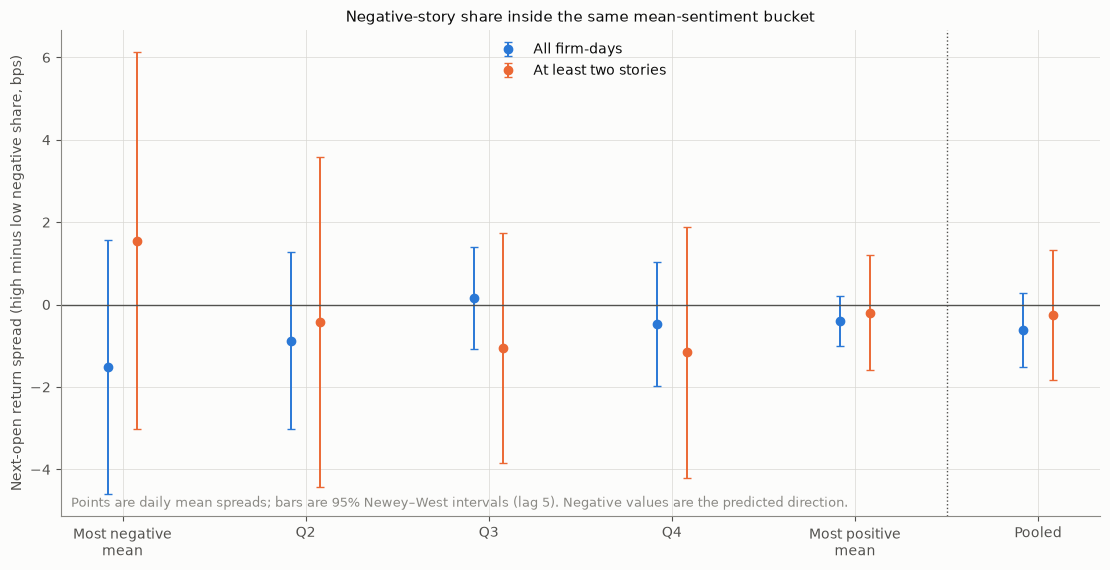

In [5]:
fig, ax = plt.subplots(figsize=(11.2, 5.8))
positions = np.arange(1, 7)
labels = ["Most negative\nmean", "Q2", "Q3", "Q4", "Most positive\nmean", "Pooled"]
styles = {
    "all_firm_days": (CATEGORICAL[0], -0.08, "All firm-days"),
    "multi_story_n_ge_2": (CATEGORICAL[1], 0.08, "At least two stories"),
}
for sample, (colour, offset, label) in styles.items():
    rows = (
        quintile_summary.loc[quintile_summary["sample"].eq(sample)]
        .set_index("mean_quintile")
        .reindex(range(1, 6))
    )
    pooled = pooled_summary.loc[pooled_summary["sample"].eq(sample)].iloc[0]
    point = np.r_[rows["mean_bps"].to_numpy(), pooled["mean_bps"]]
    low = np.r_[rows["ci_low_bps"].to_numpy(), pooled["ci_low_bps"]]
    high = np.r_[rows["ci_high_bps"].to_numpy(), pooled["ci_high_bps"]]
    ax.errorbar(
        positions + offset,
        point,
        yerr=np.vstack([point - low, high - point]),
        fmt="o",
        color=colour,
        capsize=3,
        linewidth=1.4,
        markersize=6,
        label=label,
    )
ax.axhline(0.0, color=INK["reference"], linewidth=1.0)
ax.axvline(5.5, color=INK["reference"], linestyle=":", linewidth=1.0)
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel("Next-open return spread (high minus low negative share, bps)")
ax.set_title("Negative-story share inside the same mean-sentiment bucket")
ax.legend(frameon=False, loc="best")
ax.text(
    0.01,
    0.02,
    "Points are daily mean spreads; bars are 95% Newey–West intervals (lag 5). Negative values are the predicted direction.",
    transform=ax.transAxes,
    fontsize=9,
    color=INK["muted"],
)
fig.tight_layout()
fig.savefig(OUTPUT / "conditional_double_sort.png", dpi=180, bbox_inches="tight")
fig.savefig(FIGURE_OUTPUT, dpi=180, bbox_inches="tight")
plt.show()

## Persist aggregate, licence-safe evidence

In [6]:
input_audit.to_csv(OUTPUT / "input_audit.csv", index=False)
coverage.to_csv(OUTPUT / "coverage_audit.csv", index=False)
cell_return_summary.to_csv(OUTPUT / "cell_return_summary.csv", index=False)
quintile_summary.to_csv(OUTPUT / "quintile_spread_summary.csv", index=False)
pooled_summary.to_csv(OUTPUT / "pooled_spread_summary.csv", index=False)
spread_table.to_parquet(OUTPUT / "quintile_session_spreads.parquet", index=False)
daily_table.to_parquet(OUTPUT / "daily_pooled_spreads.parquet", index=False)

git_commit = subprocess.run(
    ["git", "rev-parse", "HEAD"], cwd=ROOT, check=True, capture_output=True, text=True
).stdout.strip()
manifest = {
    "notebook": "76_fnspid_development_negative_share_double_sort",
    "status": "complete_descriptive_previously_opened_development",
    "git_commit_at_execution": git_commit,
    "declared_spec": str(SPEC_PATH.relative_to(ROOT)),
    "declared_spec_sha256": sha256(SPEC_PATH),
    "input": str(INPUT_PATH.relative_to(ROOT)),
    "input_sha256": input_hash,
    "design": declared,
    "seed": SEED,
    "coverage": json.loads(coverage.to_json(orient="records")),
    "quintile_spreads": json.loads(quintile_summary.to_json(orient="records")),
    "pooled_spreads": json.loads(pooled_summary.to_json(orient="records")),
    "figure": str(FIGURE_OUTPUT.relative_to(ROOT)),
    "claim_boundary": spec["claim_boundary"],
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=True) + "\n")

primary = pooled_summary.loc[pooled_summary["sample"].eq("all_firm_days")].iloc[0]
multi = pooled_summary.loc[pooled_summary["sample"].eq("multi_story_n_ge_2")].iloc[0]
display(
    Markdown(
        f"""### Descriptive result

- All development firm-days: **{primary['mean_bps']:+.2f} bps/session**
  (95% HAC interval **[{primary['ci_low_bps']:+.2f}, {primary['ci_high_bps']:+.2f}]**).
- At least two stories: **{multi['mean_bps']:+.2f} bps/session**
  (95% HAC interval **[{multi['ci_low_bps']:+.2f}, {multi['ci_high_bps']:+.2f}]**).

This is a conditional sort on previously opened development data. It supplies
an economic scale for the Notebook 71 claim, but it is not an independent test
and does not open or anticipate Notebook 75's evaluation block.
"""
    )
)

### Descriptive result

- All development firm-days: **-0.62 bps/session**
  (95% HAC interval **[-1.51, +0.27]**).
- At least two stories: **-0.25 bps/session**
  (95% HAC interval **[-1.82, +1.32]**).

This is a conditional sort on previously opened development data. It supplies
an economic scale for the Notebook 71 claim, but it is not an independent test
and does not open or anticipate Notebook 75's evaluation block.
